   SINGAPORE MRT - SCHEMATIC SYMBOLIC MAP 

   TRANSPORT NETWORK DATA REPORT (FULL SUMMARY)
Total Network Distance (KM):    38.70 km
Total Network Distance (Miles): 24.04 miles
Average Distance (Miles):  0.89 miles
Total Number of Stations:       28
Total Number of Connections:    27


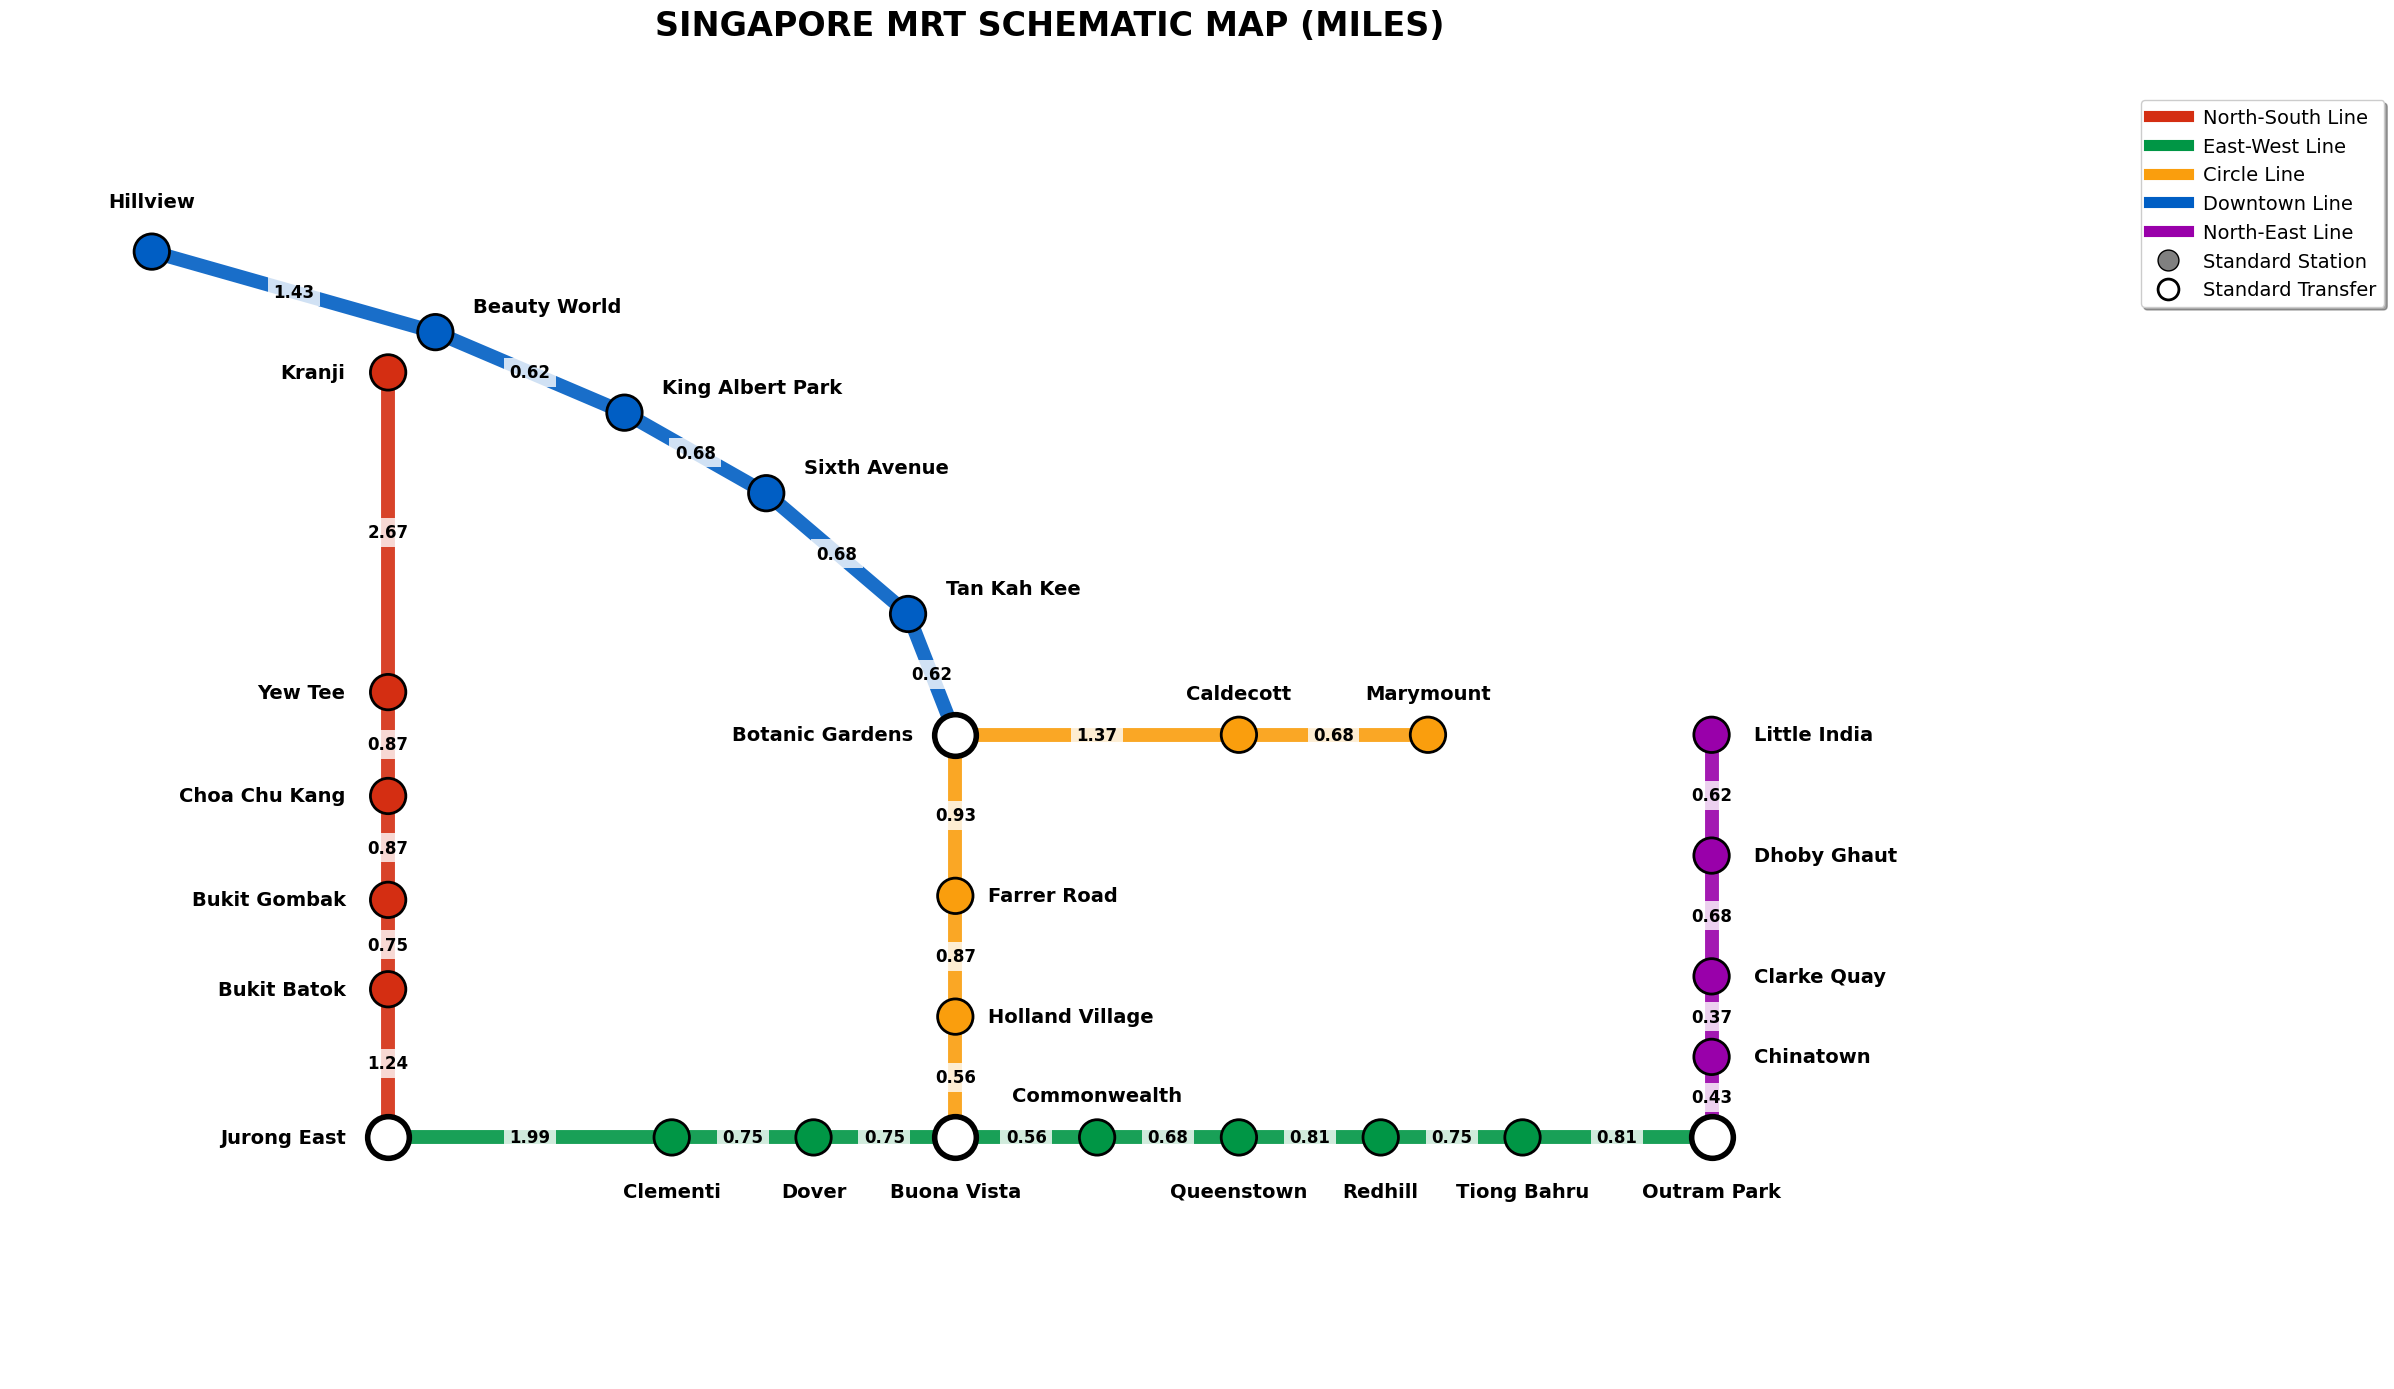

In [4]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# --- STEP 1: INITIALIZE THE GRAPH ---
G = nx.Graph()

# --- STEP 2: USER SELECTION ---
print("="*60)
print("   SINGAPORE MRT - SCHEMATIC SYMBOLIC MAP ")
print("="*60)
user_choice = input("Please select (1 for KM, 2 for Miles): ")
selected_unit = 'km' if user_choice == '1' else 'miles'
unit_label = 'KM' if user_choice == '1' else 'MILES'

# --- STEP 3: DATA SPECIFICATION ---
mrt_data = [
    ["Jurong East", "Bukit Batok", 2.0, 1.24, '#D42E12', 'North-South'],
    ["Bukit Batok", "Bukit Gombak", 1.2, 0.75, '#D42E12', 'North-South'],
    ["Bukit Gombak", "Choa Chu Kang", 1.4, 0.87, '#D42E12', 'North-South'],
    ["Choa Chu Kang", "Yew Tee", 1.4, 0.87, '#D42E12', 'North-South'],
    ["Yew Tee", "Kranji", 4.3, 2.67, '#D42E12', 'North-South'],
    ["Jurong East", "Clementi", 3.2, 1.99, '#009645', 'East-West'],
    ["Clementi", "Dover", 1.2, 0.75, '#009645', 'East-West'],
    ["Dover", "Buona Vista", 1.2, 0.75, '#009645', 'East-West'],
    ["Buona Vista", "Commonwealth", 0.9, 0.56, '#009645', 'East-West'],
    ["Commonwealth", "Queenstown", 1.1, 0.68, '#009645', 'East-West'],
    ["Queenstown", "Redhill", 1.3, 0.81, '#009645', 'East-West'],
    ["Redhill", "Tiong Bahru", 1.2, 0.75, '#009645', 'East-West'],
    ["Tiong Bahru", "Outram Park", 1.3, 0.81, '#009645', 'East-West'],
    ["Buona Vista", "Holland Village", 0.9, 0.56, '#FA9E0D', 'Circle'],
    ["Holland Village", "Farrer Road", 1.4, 0.87, '#FA9E0D', 'Circle'],
    ["Farrer Road", "Botanic Gardens", 1.5, 0.93, '#FA9E0D', 'Circle'],
    ["Botanic Gardens", "Caldecott", 2.2, 1.37, '#FA9E0D', 'Circle'],
    ["Marymount", "Caldecott", 1.1, 0.68, '#FA9E0D', 'Circle'],
    ["Botanic Gardens", "Tan Kah Kee", 1.0, 0.62, '#005EC4', 'Downtown'],
    ["Tan Kah Kee", "Sixth Avenue", 1.1, 0.68, '#005EC4', 'Downtown'],
    ["Sixth Avenue", "King Albert Park", 1.1, 0.68, '#005EC4', 'Downtown'],
    ["King Albert Park", "Beauty World", 1.0, 0.62, '#005EC4', 'Downtown'],
    ["Beauty World", "Hillview", 2.3, 1.43, '#005EC4', 'Downtown'],
    ["Outram Park", "Chinatown", 0.7, 0.43, '#9900AA', 'North-East'],
    ["Chinatown", "Clarke Quay", 0.6, 0.37, '#9900AA', 'North-East'],
    ["Clarke Quay", "Dhoby Ghaut", 1.1, 0.68, '#9900AA', 'North-East'],
    ["Dhoby Ghaut", "Little India", 1.0, 0.62, '#9900AA', 'North-East']
]

df = pd.DataFrame(mrt_data, columns=['Source', 'Target', 'km', 'miles', 'color', 'line_name'])
for _, row in df.iterrows():
    G.add_edge(row['Source'], row['Target'], km=row['km'], miles=row['miles'], color=row['color'])

# --- STEP 4: SYMBOLIC POSITIONING ---
pos = {
    #Red Line (North-South)
    "Jurong East": (0, 0), "Bukit Batok": (0, 1.84), "Bukit Gombak": (0, 2.95), 
    "Choa Chu Kang": (0, 4.24), "Yew Tee": (0, 5.53), 
    "Kranji": (0, 9.5), 
    #Green Line (East-West)
    "Clementi": (3, 0), "Dover": (4.5, 0), "Buona Vista": (6, 0), 
    "Commonwealth": (7.5, 0), "Queenstown": (9, 0), "Redhill": (10.5, 0), 
    "Tiong Bahru": (12, 0), "Outram Park": (14, 0),
    #Blue Line (North-East)
    "Chinatown": (14, 1), "Clarke Quay": (14, 2), "Dhoby Ghaut": (14, 3.5), "Little India": (14, 5),
    #Orange Line (Circle Line)
    "Holland Village": (6, 1.5), "Farrer Road": (6, 3), "Botanic Gardens": (6, 5), 
    "Caldecott": (9, 5), "Marymount": (11, 5),
    #Dark Blue Line (Downtown Line)
    "Tan Kah Kee": (5.5, 6.5), "Sixth Avenue": (4, 8), "King Albert Park": (2.5, 9), 
    "Beauty World": (0.5, 10), "Hillview": (-2.5, 11) 
}

transfer_nodes = ["Jurong East", "Buona Vista", "Botanic Gardens", "Outram Park"]
standard_nodes = [node for node in G.nodes() if node not in transfer_nodes]
standard_node_colors = [df[(df['Source'] == n) | (df['Target'] == n)].iloc[0]['color'] for n in standard_nodes]

# --- STEP 5: VISUALISATION ---
plt.figure(figsize=(24, 14), facecolor='white')

# 1. Vẽ đường ray
nx.draw_networkx_edges(G, pos, width=10, edge_color=[G[u][v]['color'] for u, v in G.edges()], alpha=0.9)

# 2. Vẽ ga thường
nx.draw_networkx_nodes(G, pos, nodelist=standard_nodes, node_size=650, 
                       node_color=standard_node_colors, edgecolors='black', linewidths=2)

# 3. Vẽ ga trung chuyển
nx.draw_networkx_nodes(G, pos, nodelist=transfer_nodes, node_size=900, 
                       node_color='white', edgecolors='black', linewidths=4)

# --- REFINED LABEL POSITIONING (TO RA) ---
label_fontsize = 14 # Chữ trạm to ra

for node, (x, y) in pos.items():
    if node == "Commonwealth":
        plt.text(x, y + 0.4, node, fontsize=label_fontsize, fontweight='bold', ha='center', va='bottom')
    elif node in ["Kranji", "Botanic Gardens"]:
        plt.text(x - 0.45, y, node, fontsize=label_fontsize, fontweight='bold', ha='right', va='center')
    elif node in ["Holland Village", "Farrer Road"]:
        plt.text(x + 0.35, y, node, fontsize=label_fontsize, fontweight='bold', ha='left', va='center')
    elif node == "Hillview":
        plt.text(x, y + 0.5, node, fontsize=label_fontsize, fontweight='bold', ha='center', va='bottom')
    elif node in ["Jurong East", "Bukit Batok", "Bukit Gombak", "Choa Chu Kang", "Yew Tee"]:
        plt.text(x - 0.45, y, node, fontsize=label_fontsize, fontweight='bold', ha='right', va='center')
    elif node in ["Clementi", "Dover", "Buona Vista", "Queenstown", "Redhill", "Tiong Bahru", "Outram Park"]:
        plt.text(x, y - 0.55, node, fontsize=label_fontsize, fontweight='bold', ha='center', va='top')
    elif node in ["Chinatown", "Clarke Quay", "Dhoby Ghaut", "Little India"]:
        plt.text(x + 0.45, y, node, fontsize=label_fontsize, fontweight='bold', ha='left', va='center')
    elif node in ["Caldecott", "Marymount"]:
        plt.text(x, y + 0.4, node, fontsize=label_fontsize, fontweight='bold', ha='center', va='bottom')
    else:
        plt.text(x + 0.4, y + 0.2, node, fontsize=label_fontsize, fontweight='bold', ha='left', va='bottom')

# --- SỐ KM/MILES TO RA VÀ NẰM NGANG ---
edge_labels = nx.get_edge_attributes(G, selected_unit)
nx.draw_networkx_edge_labels(G, pos, 
                             edge_labels={k: f"{v}" for k, v in edge_labels.items()},
                             font_size=12,      # Số KM/Miles to ra
                             font_weight='bold', 
                             rotate=False,      # ÉP CHỮ NẰM NGANG (không xoay theo đường kẻ)
                             label_pos=0.5,
                             bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))

# --- LEGEND TO RA (PHẢI) ---
handles = []
for line, color in [('North-South', '#D42E12'), ('East-West', '#009645'), ('Circle', '#FA9E0D'), ('Downtown', '#005EC4'), ('North-East', '#9900AA')]:
    handles.append(plt.Line2D([], [], color=color, label=f"{line} Line", linewidth=8)) # Đường Line trong Legend dày hơn

handles.append(plt.Line2D([], [], color='gray', label='Standard Station', marker='o', 
                          markersize=15, markeredgecolor='black', linestyle='None')) # Icon ga to hơn

handles.append(plt.Line2D([], [], color='white', label='Standard Transfer', marker='o', 
                          markersize=15, markeredgecolor='black', markeredgewidth=2, linestyle='None'))

# Legend fontsize to ra
plt.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.02, 1), 
           frameon=True, shadow=True, fontsize=14) 

plt.title(f"SINGAPORE MRT SCHEMATIC MAP ({unit_label})", fontsize=24, fontweight='bold', pad=40)
plt.xlim(-4, 18); plt.ylim(-3, 13); plt.axis('off')



# --- STEP 6: DATA REPORT ---
total_km = df['km'].sum()
total_mi = df['miles'].sum()
avg_dist = df[selected_unit].mean()

print("\n" + "="*55)
print("   TRANSPORT NETWORK DATA REPORT (FULL SUMMARY)")
print("="*55)
print(f"Total Network Distance (KM):    {total_km:.2f} km")
print(f"Total Network Distance (Miles): {total_mi:.2f} miles")
print(f"Average Distance ({selected_unit.capitalize()}):  {avg_dist:.2f} {selected_unit}")
print(f"Total Number of Stations:       {G.number_of_nodes()}")
print(f"Total Number of Connections:    {G.number_of_edges()}")
print("="*55)

plt.tight_layout()
plt.show()